<a href="https://colab.research.google.com/github/UShamila/Formative3-Group9-Probability-Bayes-GradientDescent/blob/main/Formative_3_Part_1_Probability_Distributions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [64]:
df = pd.read_csv("https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/HistData/GaltonFamilies.csv")

In [65]:
df.head()

,rownames,family,father,mother,midparentHeight,children,childNum,gender,childHeight
0,1,001,78.5,67.0,75.43,4,1,male,73.2
1,2,001,78.5,67.0,75.43,4,2,female,69.2
2,3,001,78.5,67.0,75.43,4,3,female,69.0
3,4,001,78.5,67.0,75.43,4,4,female,69.0
4,5,002,75.5,66.5,73.66,4,1,male,73.5


In [66]:
df.columns

Index(['rownames', 'family', 'father', 'mother', 'midparentHeight', 'children',
       'childNum', 'gender', 'childHeight'],
      dtype='object')

In [67]:
# Get father heights
father_heights = df["father"]

# Get children heights
child_heights = df["childHeight"]

In [68]:
# Combine both groups into one dataset
data = np.concatenate([father_heights, child_heights])

In [69]:
print("Total number of heights:", len(data))
print(data[:10])

Total number of heights: 1868
[78.5 78.5 78.5 78.5 75.5 75.5 75.5 75.5 75.  75. ]


In [70]:
mean = np.mean(data)

print("Mean:", mean)

Mean: 67.97152034261242


In [71]:
# Initial guesses for the two Gaussian distributions
mu1 = np.min(data)
mu2 = np.max(data)

sigma1 = np.var(data)
sigma2 = np.var(data)

pi1 = 0.5
pi2 = 0.5

In [72]:
def gaussian(x, mu, sigma):
    return (1 / np.sqrt(2 * np.pi * sigma)) * np.exp(-((x - mu) ** 2) / (2 * sigma))

In [73]:
def e_step(data, mu1, mu2, sigma1, sigma2, pi1, pi2):

    r1 = []
    r2 = []

    for x in data:
        p1 = pi1 * gaussian(x, mu1, sigma1)
        p2 = pi2 * gaussian(x, mu2, sigma2)

        total = p1 + p2

        r1.append(p1 / total)
        r2.append(p2 / total)

    return np.array(r1), np.array(r2)

In [74]:
r1, r2 = e_step(data, mu1, mu2, sigma1, sigma2, pi1, pi2)

In [75]:
print("First 10 responsibilities (Cluster 1):")
print(r1[:10])

print("\nFirst 10 responsibilities (Cluster 2):")
print(r2[:10])

First 10 responsibilities (Cluster 1):
[9.51386665e-11 9.51386665e-11 9.51386665e-11 9.51386665e-11
 5.14674184e-08 5.14674184e-08 5.14674184e-08 5.14674184e-08
 1.46913454e-07 1.46913454e-07]

First 10 responsibilities (Cluster 2):
[1.         1.         1.         1.         0.99999995 0.99999995
 0.99999995 0.99999995 0.99999985 0.99999985]


In [76]:
def log_likelihood(data, mu1, mu2, sigma1, sigma2, pi1, pi2):
    total_log_likelihood = 0

    for x in data:
        p1 = pi1 * gaussian(x, mu1, sigma1)
        p2 = pi2 * gaussian(x, mu2, sigma2)

        total = p1 + p2
        total_log_likelihood += np.log(total)

    return total_log_likelihood

In [77]:
ll = log_likelihood(data, mu1, mu2, sigma1, sigma2, pi1, pi2)
print("Initial Log-Likelihood:", ll)

Initial Log-Likelihood: -11945.22139403059


In [78]:
def m_step(data, r1, r2):
    N1 = np.sum(r1)
    N2 = np.sum(r2)

    mu1_new = np.sum(r1 * data) / N1
    mu2_new = np.sum(r2 * data) / N2

    sigma1_new = np.sum(r1 * (data - mu1_new)**2) / N1
    sigma2_new = np.sum(r2 * (data - mu2_new)**2) / N2

    pi1_new = N1 / len(data)
    pi2_new = N2 / len(data)

    return mu1_new, mu2_new, sigma1_new, sigma2_new, pi1_new, pi2_new

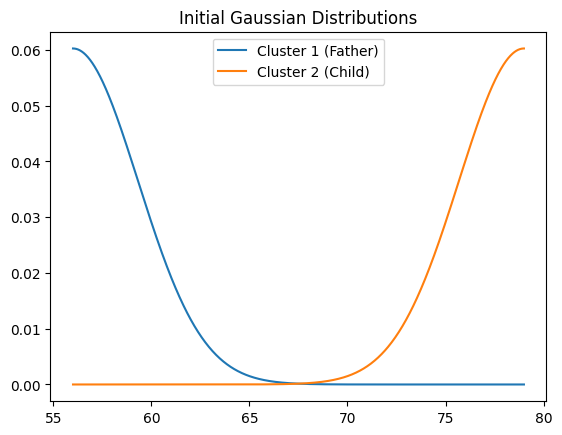

In [79]:
x = np.linspace(min(data), max(data), 1000)

y1 = pi1 * (1 / np.sqrt(2 * np.pi * sigma1)) * np.exp(-((x - mu1) ** 2) / (2 * sigma1))
y2 = pi2 * (1 / np.sqrt(2 * np.pi * sigma2)) * np.exp(-((x - mu2) ** 2) / (2 * sigma2))

plt.plot(x, y1, label="Cluster 1 (Father)")
plt.plot(x, y2, label="Cluster 2 (Child)")
plt.legend()
plt.title("Initial Gaussian Distributions")
plt.show()

In [80]:
def log_likelihood(data, mu1, mu2, sigma1, sigma2, pi1, pi2):
    p1 = pi1 * gaussian(data, mu1, sigma1)
    p2 = pi2 * gaussian(data, mu2, sigma2)
    return np.sum(np.log(p1 + p2))

In [81]:
def m_step(data, r1, r2):

    N1 = np.sum(r1)
    N2 = np.sum(r2)

    mu1_new = np.sum(r1 * data) / N1
    mu2_new = np.sum(r2 * data) / N2

    sigma1_new = np.sum(r1 * (data - mu1_new)**2) / N1
    sigma2_new = np.sum(r2 * (data - mu2_new)**2) / N2

    pi1_new = N1 / len(data)
    pi2_new = N2 / len(data)

    return mu1_new, mu2_new, sigma1_new, sigma2_new, pi1_new, pi2_new

In [82]:
def em_algorithm(data, tol=1e-4, max_iter=500):
    mu1, mu2 = np.min(data), np.max(data)
    sigma1 = sigma2 = np.var(data)
    pi1 = pi2 = 0.5

    history = []
    prev_ll = None
    converged = False

    for i in range(max_iter):
        r1, r2 = e_step(data, mu1, mu2, sigma1, sigma2, pi1, pi2)
        ll = log_likelihood(data, mu1, mu2, sigma1, sigma2, pi1, pi2)

        history.append([i, mu1, mu2, sigma1, sigma2, pi1, pi2, ll])

        if prev_ll is not None and abs(ll - prev_ll) < tol:
            print(f"Converged after {i} iterations.")
            converged = True
            break

        mu1, mu2, sigma1, sigma2, pi1, pi2 = m_step(data, r1, r2)
        prev_ll = ll

    if not converged:
        print(f"WARNING: reached max_iter={max_iter} without satisfying tol={tol}. "
              f"Increase max_iter if this happens.")

    return mu1, mu2, sigma1, sigma2, pi1, pi2, history


mu1, mu2, sigma1, sigma2, pi1, pi2, history = em_algorithm(data)

Converged after 274 iterations.


In [83]:
mu1, mu2, sigma1, sigma2, pi1, pi2 = m_step(data, r1, r2)

print(mu1, mu2, sigma1, sigma2, pi1, pi2)

64.82791509738794 70.17201721590381 4.636970329922607 3.633052944578249 0.41176175613621835 0.5882382438637815


In [84]:
def em_algorithm(data, tol=1e-4, max_iter=50):

    mu1, mu2 = np.min(data), np.max(data)
    sigma1 = sigma2 = np.var(data)
    pi1 = pi2 = 0.5

    history = []

    prev_ll = None

    # EM iterations
    for i in range(max_iter):

        # E-step
        r1, r2 = e_step(data, mu1, mu2, sigma1, sigma2, pi1, pi2)

        # log-likelihood
        ll = log_likelihood(data, mu1, mu2, sigma1, sigma2, pi1, pi2)

        # Save values
        history.append([
            i,
            mu1,
            mu2,
            sigma1,
            sigma2,
            pi1,
            pi2,
            ll
        ])

        # Check convergence
        if prev_ll is not None and abs(ll - prev_ll) < tol:
            print("Converged after", i, "iterations.")
            break

        # M-step
        mu1, mu2, sigma1, sigma2, pi1, pi2 = m_step(data, r1, r2)

        prev_ll = ll

    return mu1, mu2, sigma1, sigma2, pi1, pi2, history

In [85]:
mu1, mu2, sigma1, sigma2, pi1, pi2, history = em_algorithm(data)

In [86]:
columns = ["Iteration", "mu1", "mu2", "sigma1", "sigma2", "pi1", "pi2", "LogLikelihood"]

df_history = pd.DataFrame(history, columns=columns)

df_history

,Iteration,mu1,mu2,sigma1,sigma2,pi1,pi2,LogLikelihood
0,0,56.000000,79.000000,10.963921,10.963921,0.500000,0.500000,-11945.221394
1,1,64.827915,70.172017,4.636970,3.633053,0.411762,0.588238,-4894.571331
2,2,64.919490,70.046340,5.358682,4.137162,0.404697,0.595303,-4875.308416
3,3,64.974715,69.966341,5.798293,4.445019,0.399633,0.600367,-4868.934548
4,4,65.010956,69.909806,6.096537,4.655236,0.395661,0.604339,-4866.137949
5,5,65.035642,69.867522,6.310036,4.808168,0.392394,0.607606,-4864.714708
6,6,65.052619,69.834705,6.467735,4.924004,0.389618,0.610382,-4863.919568
7,7,65.064139,69.808549,6.586422,5.014226,0.387199,0.612801,-4863.445172
8,8,65.071638,69.787270,6.676671,5.085960,0.385049,0.614951,-4863.147407
9,9,65.076089,69.769668,6.745549,5.143907,0.383108,0.616892,-4862.952355


In [87]:
print("Required rows (iteration 0, 1, 2):")
display(df_history.head(3))

print(f"\nTotal iterations run: {len(df_history)}")
print("\nFinal converged parameters:")
print(f"mu1 (Father) = {mu1:.4f}, mu2 (Child) = {mu2:.4f}")
print(f"sigma1 = {sigma1:.4f}, sigma2 = {sigma2:.4f}")
print(f"pi1 = {pi1:.4f}, pi2 = {pi2:.4f}")
print(f"Final log-likelihood = {history[-1][-1]:.4f}")

Required rows (iteration 0, 1, 2):


,Iteration,mu1,mu2,sigma1,sigma2,pi1,pi2,LogLikelihood
0,0,56.000000,79.000000,10.963921,10.963921,0.500000,0.500000,-11945.221394
1,1,64.827915,70.172017,4.636970,3.633053,0.411762,0.588238,-4894.571331
2,2,64.919490,70.046340,5.358682,4.137162,0.404697,0.595303,-4875.308416



Total iterations run: 50

Final converged parameters:
mu1 (Father) = 64.8114, mu2 (Child) = 69.5867
sigma1 = 6.4699, sigma2 = 5.5479
pi1 = 0.3382, pi2 = 0.6618
Final log-likelihood = -4861.8828


In [88]:
def predict(height, mu1, mu2, sigma1, sigma2, pi1, pi2):
    p1 = pi1 * gaussian(height, mu1, sigma1)
    p2 = pi2 * gaussian(height, mu2, sigma2)
    total = p1 + p2

    p_father = p1 / total
    p_child = p2 / total

    print(f"Test height: {height} inches")
    print(f"P(Father | height={height}) = {p_father:.4f}")
    print(f"P(Child  | height={height}) = {p_child:.4f}")
    verdict = "Father" if p_father > p_child else "Child"
    print(f"--> Model classifies this as: {verdict}")

    return {"Father Probability": p_father, "Child Probability": p_child}


In [89]:
# Testing

In [90]:
predict(66, mu1, mu2, sigma1, sigma2, pi1, pi2)

Test height: 66 inches
P(Father | height=66) = 0.5750
P(Child  | height=66) = 0.4250
--> Model classifies this as: Father


{'Father Probability': np.float64(0.5749848579640595),
 'Child Probability': np.float64(0.4250151420359404)}